In [52]:
from pathlib import Path
from collections import Counter
import re
from typing import Dict, Iterable, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

try:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer
    from nltk import word_tokenize, sent_tokenize, pos_tag
    _nltk_available = True
except Exception:
    nltk = None
    SentimentIntensityAnalyzer = None
    word_tokenize = None
    sent_tokenize = None
    pos_tag = None
    _nltk_available = False

try:
    from transformers import pipeline
    _transformers_available = True
except Exception:
    pipeline = None
    _transformers_available = False

In [53]:
ROTATION_DIR = Path("../output").resolve()
rotation_files = sorted(ROTATION_DIR.glob("conv_item_loadings_rotated_*.csv"))

rotation_frames: Dict[str, Dict[str, object]] = {}
for path in rotation_files:
    df = pd.read_csv(path)
    factor_cols = [col for col in df.columns if col.lower().startswith("factor_")]
    rotation_frames[path.stem] = {
        "path": path,
        "df": df,
        "factor_cols": factor_cols
    }

rotation_summary = pd.DataFrame({
    "rotation": list(rotation_frames.keys()),
    "rows": [meta["df"].shape[0] for meta in rotation_frames.values()],
    "factor_columns": [meta["factor_cols"] for meta in rotation_frames.values()],
})
rotation_summary

,rotation,rows,factor_columns
0,conv_item_loadings_rotated_geomin_obl,1997,"[Factor_1, Factor_2]"
1,conv_item_loadings_rotated_oblimax,1997,"[Factor_1, Factor_2]"
2,conv_item_loadings_rotated_oblimin,1997,"[Factor_1, Factor_2]"
3,conv_item_loadings_rotated_promax,1997,"[Factor_1, Factor_2]"
4,conv_item_loadings_rotated_quartimin,1997,"[Factor_1, Factor_2]"


In [70]:
if _transformers_available:
    try:
        certainty_pipeline = pipeline(
            "zero-shot-classification",
            model="facebook/bart-large-mnli",
        )
    except Exception as exc:
        certainty_pipeline = None
        certainty_status = f"unavailable ({exc})"
    else:
        certainty_status = "available"
else:
    certainty_pipeline = None
    certainty_status = "unavailable (transformers not installed)"

sentiment_status, certainty_status

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use mps:0


('available', 'available')

In [ ]:
def _certainty_metrics(questions: Iterable[str]) -> Dict[str, float]:
    if certainty_pipeline is None:
        return {
            "certainty_score_mean": np.nan,
            "certainty_score_std": np.nan,
        }
    clean_texts = [q.strip() for q in questions if isinstance(q, str) and q.strip()]
    if not clean_texts:
        return {
            "certainty_score_mean": np.nan,
            "certainty_score_std": np.nan,
        }
    try:
        outputs = certainty_pipeline(clean_texts, candidate_labels=CERTAINTY_LABELS, multi_label=False)
    except Exception:
        return {
            "certainty_score_mean": np.nan,
            "certainty_score_std": np.nan,
        }
    if isinstance(outputs, dict):
        outputs = [outputs]
    confidences: List[float] = []
    for result in outputs:
        labels = result.get("labels", [])
        scores = result.get("scores", [])
        label_scores = dict(zip(labels, scores))
        confident_score = label_scores.get(CERTAINTY_LABELS[0])
        if confident_score is not None:
            confidences.append(float(confident_score))
    if not confidences:
        return {
            "certainty_score_mean": np.nan,
            "certainty_score_std": np.nan,
        }
    return {
        "certainty_score_mean": float(np.mean(confidences)),
        "certainty_score_std": float(np.std(confidences, ddof=0)),
    }

In [59]:
summary_rows: List[Dict[str, object]] = []
type_count_rows: List[Dict[str, object]] = []
answer_count_rows: List[Dict[str, object]] = []
top_examples: List[Dict[str, object]] = []

for rotation_name, meta in rotation_frames.items():
    df = meta["df"]
    factor_cols: List[str] = meta["factor_cols"]
    available_columns = set(df.columns.str.lower())
    has_question = "question" in df.columns
    has_type = "type" in df.columns
    has_answer = "answer" in df.columns

    for factor_col in factor_cols:
        for polarity, cluster_label in (("positive", "positive_top"), ("negative", "negative_top")):
            subset = _select_cluster(df, factor_col, polarity, TOP_N)
            stats = _loading_stats(subset, factor_col)

            if has_question:
                questions_iterable = subset["question"].fillna("")
            else:
                questions_iterable = []

            word_metrics = _word_stats(questions_iterable)
            sentiment_metrics = _sentiment_metrics(questions_iterable)
            certainty_metrics = _certainty_metrics(questions_iterable)

            summary_rows.append({
                "rotation": rotation_name,
                "factor": factor_col,
                "cluster": cluster_label,
                **stats,
                **word_metrics,
                **sentiment_metrics,
                **certainty_metrics,
            })

            if has_type and not subset.empty:
                type_counts = subset["type"].value_counts().to_dict()
                type_count_rows.append({
                    "rotation": rotation_name,
                    "factor": factor_col,
                    "cluster": cluster_label,
                    **{f"type_{k}": int(v) for k, v in type_counts.items()},
                })
            elif not has_type:
                type_count_rows.append({
                    "rotation": rotation_name,
                    "factor": factor_col,
                    "cluster": cluster_label,
                    "note": "type column missing",
                })

            if has_answer and not subset.empty:
                answer_counts = subset["answer"].value_counts().to_dict()
                answer_count_rows.append({
                    "rotation": rotation_name,
                    "factor": factor_col,
                    "cluster": cluster_label,
                    **{f"answer_{k}": int(v) for k, v in answer_counts.items()},
                })
            elif not has_answer:
                answer_count_rows.append({
                    "rotation": rotation_name,
                    "factor": factor_col,
                    "cluster": cluster_label,
                    "note": "answer column missing",
                })

            if has_question and not subset.empty:
                top_sample = subset[["question", factor_col]].head(5)
                for idx, row in top_sample.iterrows():
                    top_examples.append({
                        "rotation": rotation_name,
                        "factor": factor_col,
                        "cluster": cluster_label,
                        "rank": idx,
                        "question": row["question"],
                        "loading": row[factor_col],
                    })

In [60]:
summary_df = pd.DataFrame(summary_rows)
type_counts_df = pd.DataFrame(type_count_rows).fillna(0) if type_count_rows else pd.DataFrame()
answer_counts_df = pd.DataFrame(answer_count_rows).fillna(0) if answer_count_rows else pd.DataFrame()
examples_df = pd.DataFrame(top_examples) if top_examples else pd.DataFrame()

summary_df.sort_values(["rotation", "factor", "cluster"], inplace=True)
summary_df

,rotation,factor,cluster,count,loading_mean,loading_median,loading_std,loading_min,loading_max,word_count_total,...,lexical_diversity,long_word_ratio,sentence_length_mean,sentence_length_std,burstiness,modal_word_ratio,sentiment_mean,sentiment_std,certainty_score_mean,certainty_score_std
1,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,877,-0.739054,-0.639409,0.572519,-2.556265,-0.000266,262880,...,0.045382,0.338888,32.172317,27.543598,0.856127,0.0,0.231453,0.569824,NaN,NaN
0,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,1000,1.040226,0.923509,0.676337,0.131626,3.017735,257662,...,0.043805,0.346904,31.657698,25.377282,0.801615,0.0,0.170738,0.550980,NaN,NaN
3,conv_item_loadings_rotated_geomin_obl,Factor_2,negative_top,395,-0.508538,-0.440605,0.385251,-1.682391,-0.002383,51241,...,0.119592,0.320193,27.169141,24.696858,0.909004,0.0,0.024543,0.495984,NaN,NaN
2,conv_item_loadings_rotated_geomin_obl,Factor_2,positive_top,1000,1.321055,1.125869,0.618248,0.621236,3.376785,429182,...,0.030798,0.347263,33.357842,26.050088,0.780928,0.0,0.337286,0.611471,NaN,NaN
5,conv_item_loadings_rotated_oblimax,Factor_1,negative_top,1000,-1.346167,-1.178474,0.622833,-3.390332,-0.590878,432773,...,0.030871,0.347381,33.333821,25.978053,0.779330,0.0,0.349941,0.606733,NaN,NaN
4,conv_item_loadings_rotated_oblimax,Factor_1,positive_top,446,0.553324,0.457686,0.435487,0.000242,2.034376,54541,...,0.114263,0.319814,27.504286,27.573070,1.002501,0.0,0.042996,0.482157,NaN,NaN
7,conv_item_loadings_rotated_oblimax,Factor_2,negative_top,1000,-1.020010,-0.903199,0.677223,-2.983663,-0.106542,248263,...,0.045238,0.345319,31.449582,25.371173,0.806725,0.0,0.159988,0.546469,NaN,NaN
6,conv_item_loadings_rotated_oblimax,Factor_2,positive_top,896,0.737458,0.626405,0.567975,0.000135,2.572546,277871,...,0.043938,0.339971,32.336902,27.388579,0.846976,0.0,0.239182,0.574956,NaN,NaN
9,conv_item_loadings_rotated_oblimin,Factor_1,negative_top,885,-0.754194,-0.643140,0.580927,-2.615097,-0.000025,268694,...,0.044672,0.339490,32.217506,27.446699,0.851919,0.0,0.236332,0.570718,NaN,NaN
8,conv_item_loadings_rotated_oblimin,Factor_1,positive_top,1000,1.049779,0.929798,0.690098,0.117731,3.058756,250005,...,0.045087,0.345661,31.470921,25.313655,0.804351,0.0,0.161481,0.547614,NaN,NaN


In [61]:
if not type_counts_df.empty:
    type_counts_df = type_counts_df.sort_values(["rotation", "factor", "cluster"])
type_counts_df

,rotation,factor,cluster,type_international_citizenship,type_corporate_lobbying,type_function_of_decision_section,type_abercrombie,type_proa
1,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,374,227,134,75,67
0,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,623,215,134,14,14
3,conv_item_loadings_rotated_geomin_obl,Factor_2,negative_top,240,31,110,11,3
2,conv_item_loadings_rotated_geomin_obl,Factor_2,positive_top,382,391,104,45,78
5,conv_item_loadings_rotated_oblimax,Factor_1,negative_top,360,395,108,54,83
4,conv_item_loadings_rotated_oblimax,Factor_1,positive_top,288,32,114,10,2
7,conv_item_loadings_rotated_oblimax,Factor_2,negative_top,623,205,143,15,14
6,conv_item_loadings_rotated_oblimax,Factor_2,positive_top,374,241,136,76,69
9,conv_item_loadings_rotated_oblimin,Factor_1,negative_top,374,233,134,76,68
8,conv_item_loadings_rotated_oblimin,Factor_1,positive_top,623,207,141,15,14


In [62]:
if not answer_counts_df.empty:
    answer_counts_df = answer_counts_df.sort_values(["rotation", "factor", "cluster"])
answer_counts_df

,rotation,factor,cluster,answer_No,answer_Issue,answer_Procedural History,answer_Rule,answer_Conclusion,answer_Facts,answer_Analysis,answer_Decree,answer_suggestive,answer_descriptive,answer_Yes,answer_generic,answer_arbitrary,answer_fanciful
1,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,110,8,18,26,10,27,33,12,12,14,558,16.0,15.0,18.0
0,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,848,33,31,19,14,13,12,12,6,4,4,2.0,2.0,0.0
3,conv_item_loadings_rotated_geomin_obl,Factor_2,negative_top,183,33,27,14,9,11,12,4,4,5,91,1.0,1.0,0.0
2,conv_item_loadings_rotated_geomin_obl,Factor_2,positive_top,516,5,9,22,6,19,27,16,5,4,335,15.0,8.0,13.0
5,conv_item_loadings_rotated_oblimax,Factor_1,negative_top,458,5,10,23,6,19,29,16,6,5,380,16.0,11.0,16.0
4,conv_item_loadings_rotated_oblimax,Factor_1,positive_top,257,34,26,14,10,13,12,5,4,5,65,0.0,1.0,0.0
7,conv_item_loadings_rotated_oblimax,Factor_2,negative_top,838,36,32,20,15,13,14,13,6,4,4,2.0,3.0,0.0
6,conv_item_loadings_rotated_oblimax,Factor_2,positive_top,126,9,19,27,10,27,32,12,12,14,558,16.0,15.0,19.0
9,conv_item_loadings_rotated_oblimin,Factor_1,negative_top,117,8,18,27,10,27,32,12,12,14,558,16.0,15.0,19.0
8,conv_item_loadings_rotated_oblimin,Factor_1,positive_top,840,34,32,20,15,13,14,13,6,4,4,2.0,3.0,0.0


In [63]:
examples_df.head(20)

,rotation,factor,cluster,rank,question,loading
0,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,1149,Question: Consider the country of Moldova. Doe...,3.017735
1,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,963,Question: Consider the country of Iran. Does t...,2.918273
2,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,1016,Question: Consider the country of Kenya. Does ...,2.908518
3,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,1452,Question: Consider the country of Tanzania. Do...,2.821050
4,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,1086,Question: Consider the country of Lithuania. D...,2.807497
5,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,853,Question: Consider the country of Ethiopia. Do...,-2.556265
6,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,594,Question: Consider the country of Angola. Does...,-2.549211
7,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,912,Question: Consider the country of Guinea. Does...,-2.497622
8,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,888,Question: Consider the country of Georgia. Doe...,-2.463986
9,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,1413,Question: Consider the country of Sudan. Does ...,-2.319718


In [64]:
rotation_overview = (
    summary_df.groupby(["rotation", "cluster"])
    [["count", "loading_mean", "word_count_mean", "sentence_length_mean", "certainty_score_mean"]]
    .agg(["mean", "median"])
)
rotation_overview

count          \
                                                      mean  median   
rotation                              cluster                        
conv_item_loadings_rotated_geomin_obl negative_top   636.0   636.0   
                                      positive_top  1000.0  1000.0   
conv_item_loadings_rotated_oblimax    negative_top  1000.0  1000.0   
                                      positive_top   671.0   671.0   
conv_item_loadings_rotated_oblimin    negative_top   627.5   627.5   
                                      positive_top  1000.0  1000.0   
conv_item_loadings_rotated_promax     negative_top  1000.0  1000.0   
                                      positive_top   604.0   604.0   
conv_item_loadings_rotated_quartimin  negative_top   627.5   627.5   
                                      positive_top  1000.0  1000.0   

                                                   loading_mean            \
                                                           mean    median   
rotation                              cluster                               
conv_item_loadings_rotated_geomin_obl negative_top    -0.623796 -0.623796   
                                      positive_top     1.180641  1.180641   
conv_item_loadings_rotated_oblimax    negative_top    -1.183088 -1.183088   
                                      positive_top     0.645391  0.645391   
conv_item_loadings_rotated_oblimin    negative_top    -0.624857 -0.624857   
                                      positive_top     1.180888  1.180888   
conv_item_loadings_rotated_promax     negative_top    -1.229089 -1.229089   
                                      positive_top     0.632841  0.632841   
conv_item_loadings_rotated_quartimin  negative_top    -0.624857 -0.624857   
                                      positive_top     1.180888  1.180888   

                                                   word_count_mean  \
                                                              mean   
rotation                              cluster                        
conv_item_loadings_rotated_geomin_obl negative_top      214.736598   
                                      positive_top      343.422000   
conv_item_loadings_rotated_oblimax    negative_top      340.518000   
                                      positive_top      216.206561   
conv_item_loadings_rotated_oblimin    negative_top      213.539655   
                                      positive_top      337.924500   
conv_item_loadings_rotated_promax     negative_top      376.261500   
                                      positive_top      180.422894   
conv_item_loadings_rotated_quartimin  negative_top      213.539655   
                                      positive_top      337.924500   

                                                                \
                                                        median   
rotation                              cluster                    
conv_item_loadings_rotated_geomin_obl negative_top  214.736598   
                                      positive_top  343.422000   
conv_item_loadings_rotated_oblimax    negative_top  340.518000   
                                      positive_top  216.206561   
conv_item_loadings_rotated_oblimin    negative_top  213.539655   
                                      positive_top  337.924500   
conv_item_loadings_rotated_promax     negative_top  376.261500   
                                      positive_top  180.422894   
conv_item_loadings_rotated_quartimin  negative_top  213.539655   
                                      positive_top  337.924500   

                                                   sentence_length_mean  \
                                                                   mean   
rotation                              cluster                             
conv_item_loadings_rotated_geomin_obl negative_top            29.670729   
                                      positive_top            32.50777

In [65]:
summary_df.loc[:, ["rotation", "factor", "cluster", "count", "loading_mean", "word_count_mean", "sentence_length_mean", "certainty_score_mean", "modal_word_ratio"]].head(12)

,rotation,factor,cluster,count,loading_mean,word_count_mean,sentence_length_mean,certainty_score_mean,modal_word_ratio
1,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,877,-0.739054,299.749145,32.172317,NaN,0.0
0,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,1000,1.040226,257.662000,31.657698,NaN,0.0
3,conv_item_loadings_rotated_geomin_obl,Factor_2,negative_top,395,-0.508538,129.724051,27.169141,NaN,0.0
2,conv_item_loadings_rotated_geomin_obl,Factor_2,positive_top,1000,1.321055,429.182000,33.357842,NaN,0.0
5,conv_item_loadings_rotated_oblimax,Factor_1,negative_top,1000,-1.346167,432.773000,33.333821,NaN,0.0
4,conv_item_loadings_rotated_oblimax,Factor_1,positive_top,446,0.553324,122.289238,27.504286,NaN,0.0
7,conv_item_loadings_rotated_oblimax,Factor_2,negative_top,1000,-1.020010,248.263000,31.449582,NaN,0.0
6,conv_item_loadings_rotated_oblimax,Factor_2,positive_top,896,0.737458,310.123884,32.336902,NaN,0.0
9,conv_item_loadings_rotated_oblimin,Factor_1,negative_top,885,-0.754194,303.609040,32.217506,NaN,0.0
8,conv_item_loadings_rotated_oblimin,Factor_1,positive_top,1000,1.049779,250.005000,31.470921,NaN,0.0


In [66]:
{
    "records_per_rotation": summary_df.groupby("rotation")["count"].sum().to_dict(),
    "avg_word_count_by_rotation": summary_df.groupby("rotation")["word_count_mean"].mean().round(2).to_dict(),
    "avg_certainty_by_rotation": summary_df.groupby("rotation")["certainty_score_mean"].mean().round(3).to_dict(),
    "avg_modal_ratio_by_rotation": summary_df.groupby("rotation")["modal_word_ratio"].mean().round(4).to_dict(),
}

{'records_per_rotation': {'conv_item_loadings_rotated_geomin_obl': 3272,
  'conv_item_loadings_rotated_oblimax': 3342,
  'conv_item_loadings_rotated_oblimin': 3255,
  'conv_item_loadings_rotated_promax': 3208,
  'conv_item_loadings_rotated_quartimin': 3255},
 'avg_word_count_by_rotation': {'conv_item_loadings_rotated_geomin_obl': 279.08,
  'conv_item_loadings_rotated_oblimax': 278.36,
  'conv_item_loadings_rotated_oblimin': 275.73,
  'conv_item_loadings_rotated_promax': 278.34,
  'conv_item_loadings_rotated_quartimin': 275.73},
 'avg_certainty_by_rotation': {'conv_item_loadings_rotated_geomin_obl': nan,
  'conv_item_loadings_rotated_oblimax': nan,
  'conv_item_loadings_rotated_oblimin': nan,
  'conv_item_loadings_rotated_promax': nan,
  'conv_item_loadings_rotated_quartimin': nan},
 'avg_modal_ratio_by_rotation': {'conv_item_loadings_rotated_geomin_obl': 0.0,
  'conv_item_loadings_rotated_oblimax': 0.0,
  'conv_item_loadings_rotated_oblimin': 0.0,
  'conv_item_loadings_rotated_promax':

In [68]:
plot_summary_df = summary_df.copy()
plot_summary_df["rotation_pretty"] = (
    plot_summary_df["rotation"]
    .str.replace("conv_item_loadings_rotated_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
 )
plot_summary_df["cluster_label"] = (
    plot_summary_df["cluster"]
    .str.replace("_top", "", regex=False)
    .str.replace("_", " ")
    .str.title()
 )
plot_summary_df.head()

,rotation,factor,cluster,count,loading_mean,loading_median,loading_std,loading_min,loading_max,word_count_total,...,sentence_length_mean,sentence_length_std,burstiness,modal_word_ratio,sentiment_mean,sentiment_std,certainty_score_mean,certainty_score_std,rotation_pretty,cluster_label
1,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,877,-0.739054,-0.639409,0.572519,-2.556265,-0.000266,262880,...,32.172317,27.543598,0.856127,0.0,0.231453,0.569824,NaN,NaN,Geomin Obl,Negative
0,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,1000,1.040226,0.923509,0.676337,0.131626,3.017735,257662,...,31.657698,25.377282,0.801615,0.0,0.170738,0.550980,NaN,NaN,Geomin Obl,Positive
3,conv_item_loadings_rotated_geomin_obl,Factor_2,negative_top,395,-0.508538,-0.440605,0.385251,-1.682391,-0.002383,51241,...,27.169141,24.696858,0.909004,0.0,0.024543,0.495984,NaN,NaN,Geomin Obl,Negative
2,conv_item_loadings_rotated_geomin_obl,Factor_2,positive_top,1000,1.321055,1.125869,0.618248,0.621236,3.376785,429182,...,33.357842,26.050088,0.780928,0.0,0.337286,0.611471,NaN,NaN,Geomin Obl,Positive
5,conv_item_loadings_rotated_oblimax,Factor_1,negative_top,1000,-1.346167,-1.178474,0.622833,-3.390332,-0.590878,432773,...,33.333821,25.978053,0.779330,0.0,0.349941,0.606733,NaN,NaN,Oblimax,Negative


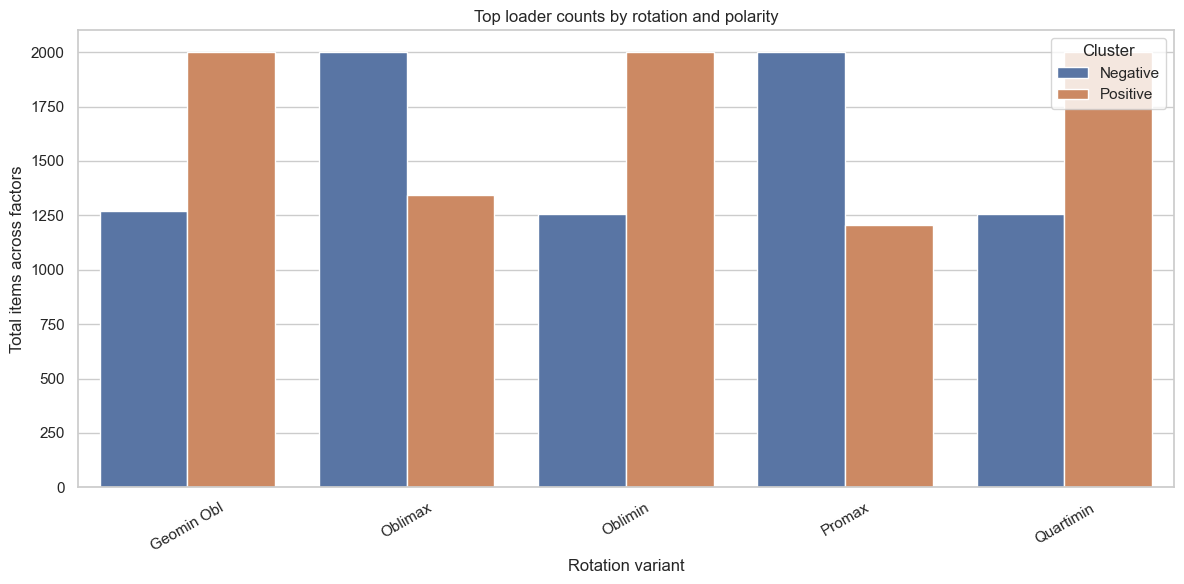

In [41]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=plot_summary_df,
    x="rotation_pretty",
    y="count",
    hue="cluster_label",
    estimator="sum",
    errorbar=None,
    ax=ax,
)
ax.set_title("Top loader counts by rotation and polarity")
ax.set_xlabel("Rotation variant")
ax.set_ylabel("Total items across factors")
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [42]:
metrics_to_plot = [
    "loading_mean",
    "loading_std",
    "word_count_mean",
    "lexical_diversity",
    "sentence_length_mean",
    "burstiness",
    "certainty_score_mean",
    "modal_word_ratio",
    "sentiment_mean",
 ]
metric_long = plot_summary_df.melt(
    id_vars=["rotation_pretty", "cluster_label", "factor"],
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="value",
)
metric_long.dropna(subset=["value"], inplace=True)
metric_long.head()

,rotation_pretty,cluster_label,factor,metric,value
0,Geomin Obl,Negative,Factor_1,loading_mean,-0.739054
1,Geomin Obl,Positive,Factor_1,loading_mean,1.040226
2,Geomin Obl,Negative,Factor_2,loading_mean,-0.508538
3,Geomin Obl,Positive,Factor_2,loading_mean,1.321055
4,Oblimax,Negative,Factor_1,loading_mean,-1.346167


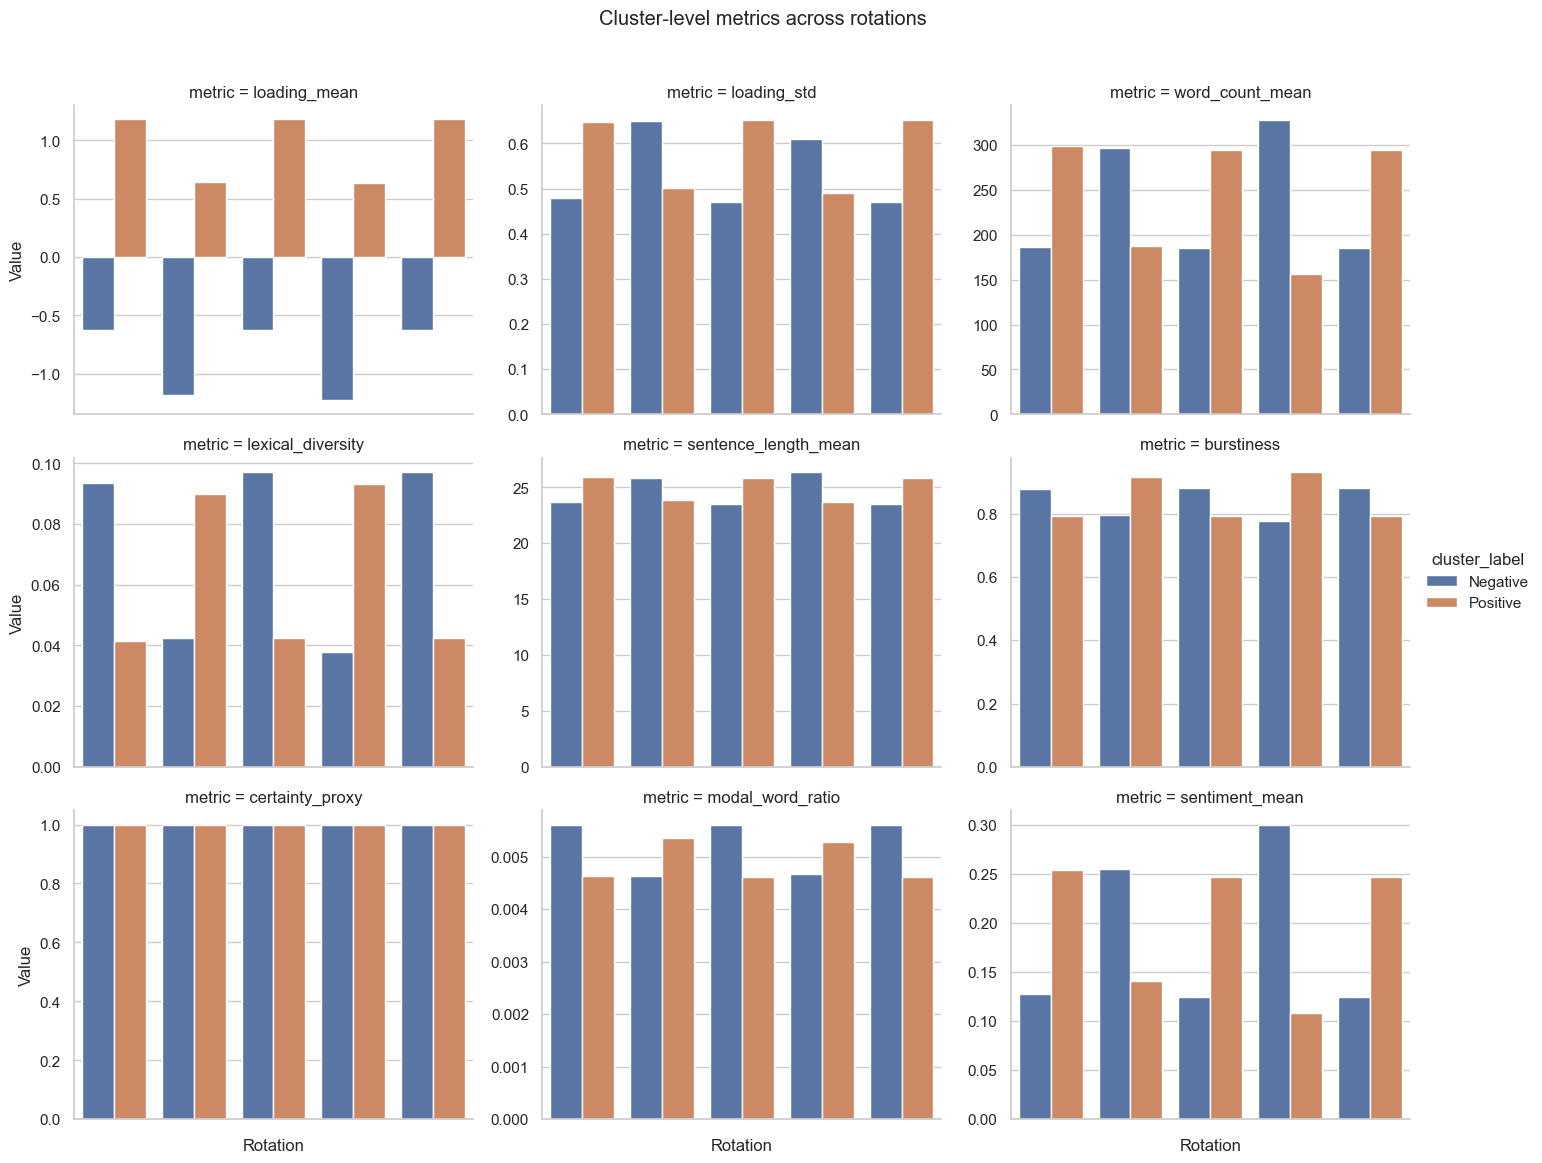

In [43]:
g = sns.catplot(
    data=metric_long,
    x="rotation_pretty",
    y="value",
    hue="cluster_label",
    col="metric",
    col_wrap=3,
    kind="bar",
    sharey=False,
    height=4,
    aspect=1.2,
    errorbar=None,
)
g.set_xticklabels(rotation=45)
g.set_axis_labels("Rotation", "Value")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Cluster-level metrics across rotations")
plt.show()

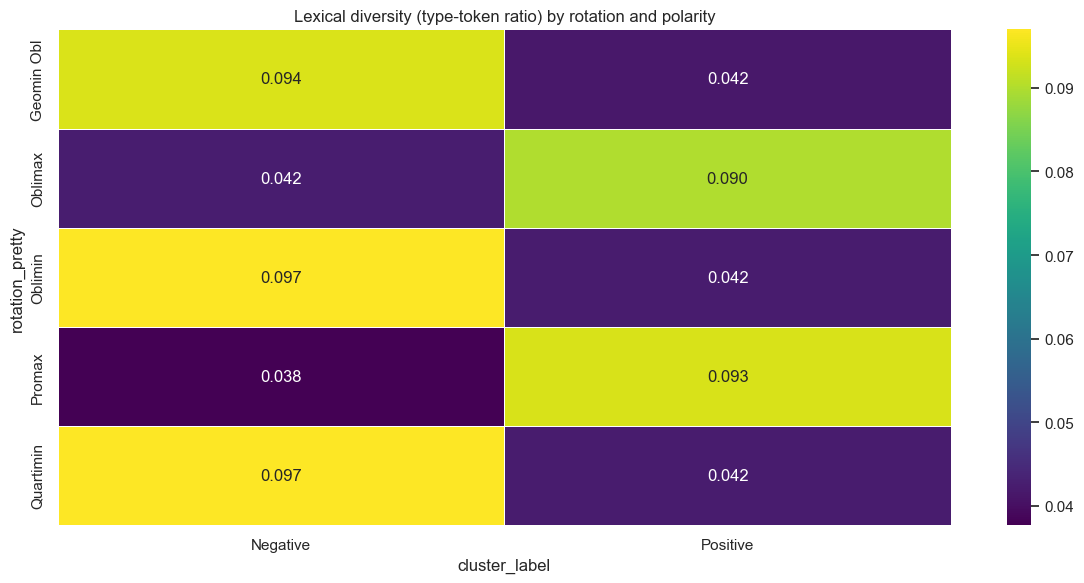

In [44]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    plot_summary_df.pivot_table(
        index="rotation_pretty",
        columns="cluster_label",
        values="lexical_diversity",
        aggfunc="mean",
    ),
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    cmap="viridis",
    ax=ax,
)
ax.set_title("Lexical diversity (type-token ratio) by rotation and polarity")
plt.tight_layout()
plt.show()

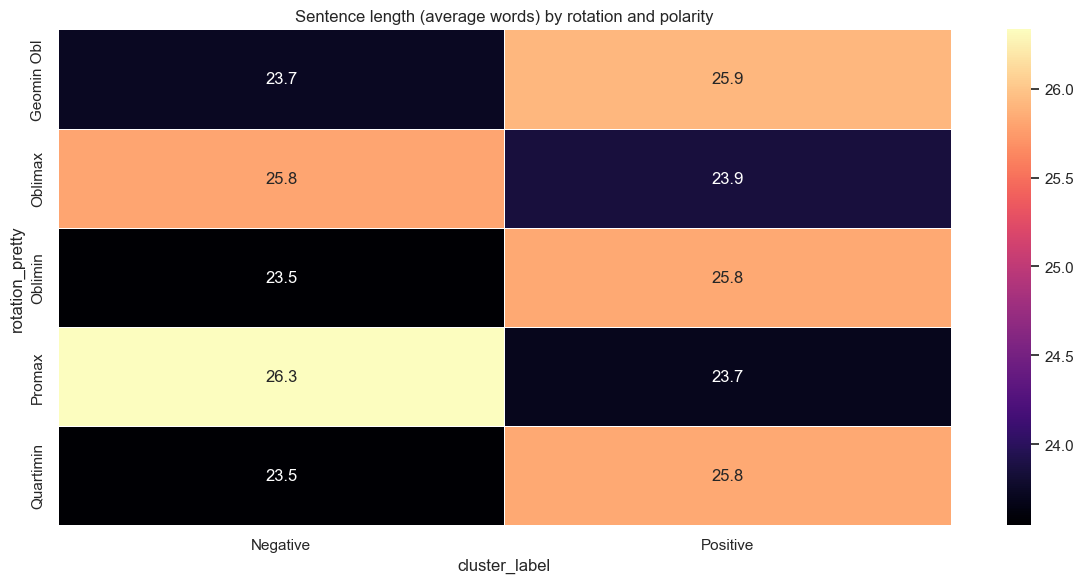

In [45]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    plot_summary_df.pivot_table(
        index="rotation_pretty",
        columns="cluster_label",
        values="sentence_length_mean",
        aggfunc="mean",
    ),
    annot=True,
    fmt=".1f",
    linewidths=0.5,
    cmap="magma",
    ax=ax,
)
ax.set_title("Sentence length (average words) by rotation and polarity")
plt.tight_layout()
plt.show()

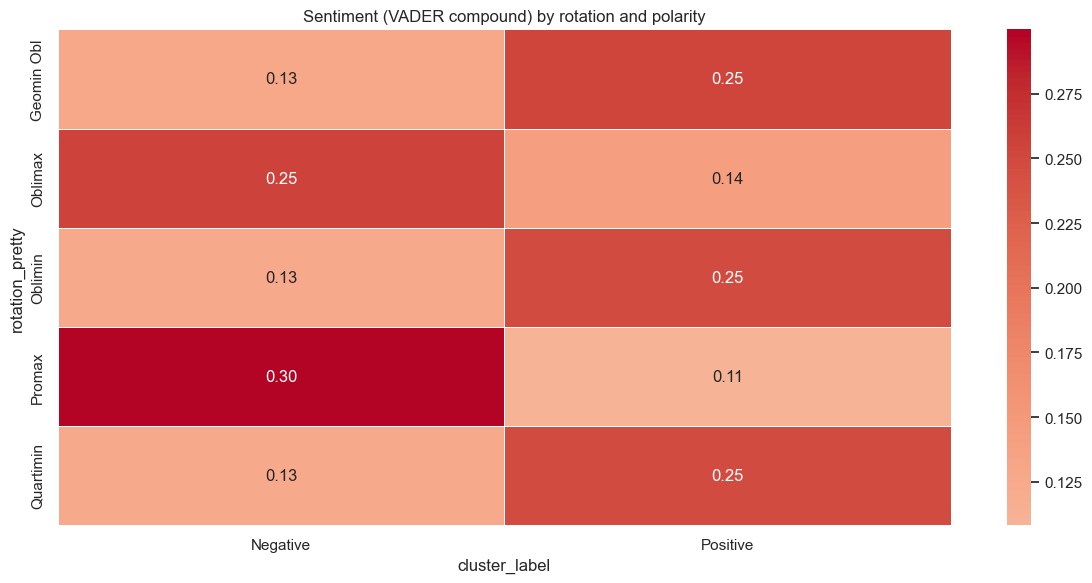

In [46]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    plot_summary_df.pivot_table(
        index="rotation_pretty",
        columns="cluster_label",
        values="sentiment_mean",
        aggfunc="mean",
    ),
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="coolwarm",
    center=0,
    ax=ax,
)
ax.set_title("Sentiment (VADER compound) by rotation and polarity")
plt.tight_layout()
plt.show()

In [47]:
type_long = type_counts_df.melt(
    id_vars=["rotation", "factor", "cluster"],
    var_name="type_label",
    value_name="count",
)
type_long = type_long[type_long["type_label"].str.startswith("type_")]
type_long["type_label"] = type_long["type_label"].str.replace("type_", "", regex=False)
type_long["rotation_pretty"] = type_long["rotation"].str.replace("conv_item_loadings_rotated_", "", regex=False).str.replace("_", " ").str.title()
type_long["cluster_label"] = type_long["cluster"].str.replace("_top", "", regex=False).str.replace("_", " ").str.title()
type_long.head()

,rotation,factor,cluster,type_label,count,rotation_pretty,cluster_label
0,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,international_citizenship,374,Geomin Obl,Negative
1,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,international_citizenship,623,Geomin Obl,Positive
2,conv_item_loadings_rotated_geomin_obl,Factor_2,negative_top,international_citizenship,240,Geomin Obl,Negative
3,conv_item_loadings_rotated_geomin_obl,Factor_2,positive_top,international_citizenship,382,Geomin Obl,Positive
4,conv_item_loadings_rotated_oblimax,Factor_1,negative_top,international_citizenship,360,Oblimax,Negative


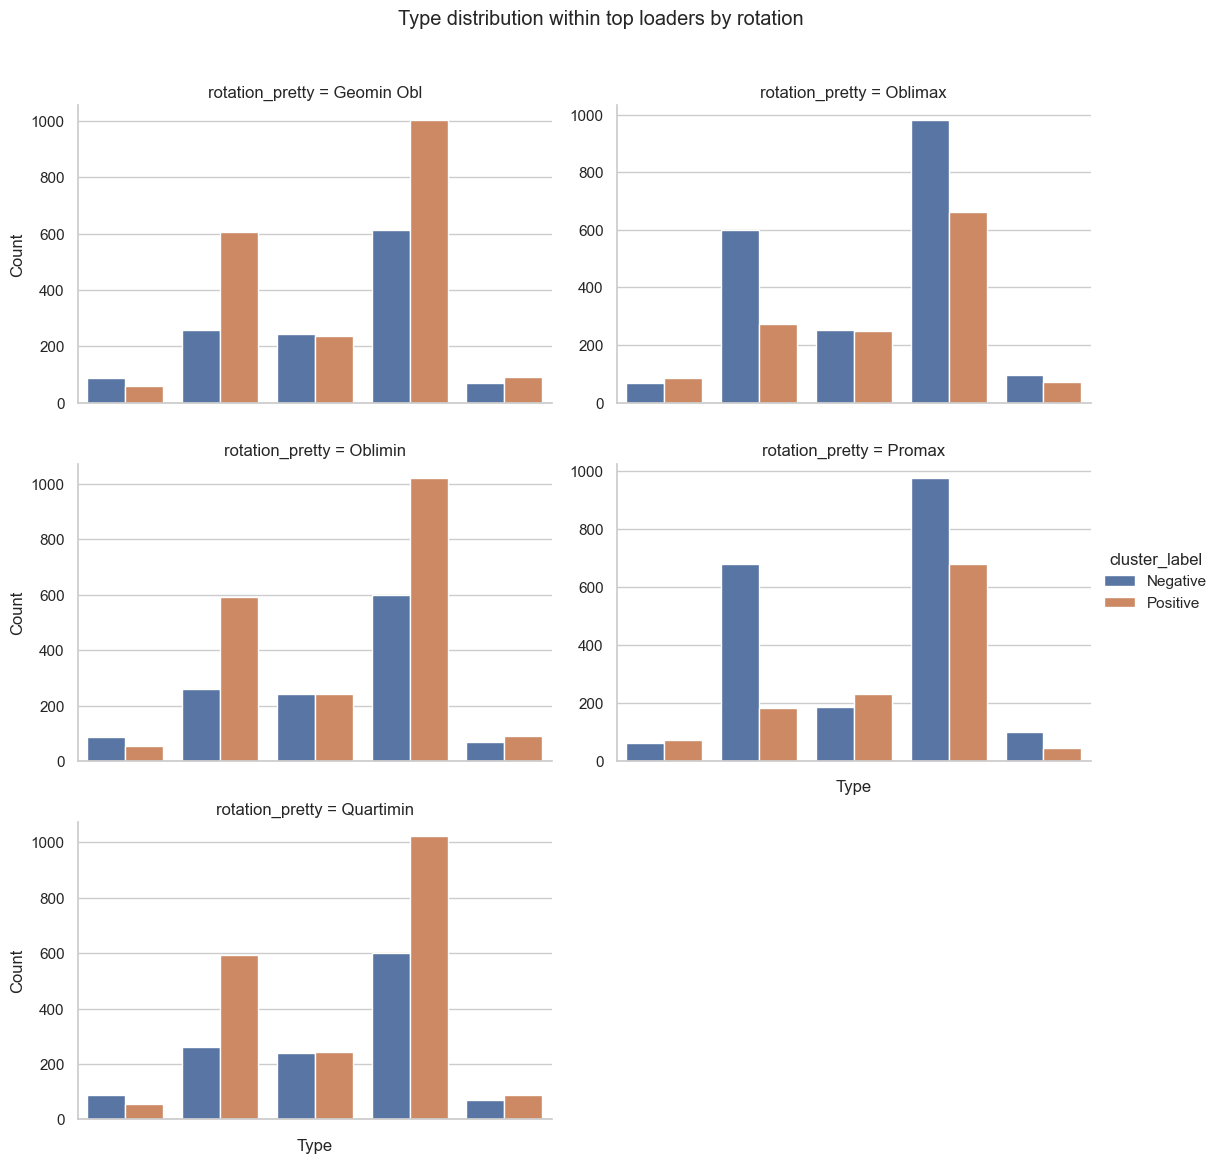

In [48]:
top_types = (
    type_long.groupby(["rotation_pretty", "cluster_label", "type_label"])
    ["count"]
    .sum()
    .reset_index()
 )

g = sns.catplot(
    data=top_types,
    x="type_label",
    y="count",
    hue="cluster_label",
    col="rotation_pretty",
    kind="bar",
    col_wrap=2,
    height=4,
    aspect=1.4,
    sharey=False,
    errorbar=None,
)
g.set_xticklabels(rotation=90)
g.set_axis_labels("Type", "Count")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Type distribution within top loaders by rotation")
plt.show()

In [49]:
answer_long = answer_counts_df.melt(
    id_vars=["rotation", "factor", "cluster"],
    var_name="answer_label",
    value_name="count",
)
answer_long = answer_long[answer_long["answer_label"].str.startswith("answer_")]
answer_long["answer_label"] = answer_long["answer_label"].str.replace("answer_", "", regex=False)
answer_long["rotation_pretty"] = answer_long["rotation"].str.replace("conv_item_loadings_rotated_", "", regex=False).str.replace("_", " ").str.title()
answer_long["cluster_label"] = answer_long["cluster"].str.replace("_top", "", regex=False).str.replace("_", " ").str.title()
answer_long.head()

,rotation,factor,cluster,answer_label,count,rotation_pretty,cluster_label
0,conv_item_loadings_rotated_geomin_obl,Factor_1,negative_top,No,110.0,Geomin Obl,Negative
1,conv_item_loadings_rotated_geomin_obl,Factor_1,positive_top,No,848.0,Geomin Obl,Positive
2,conv_item_loadings_rotated_geomin_obl,Factor_2,negative_top,No,183.0,Geomin Obl,Negative
3,conv_item_loadings_rotated_geomin_obl,Factor_2,positive_top,No,516.0,Geomin Obl,Positive
4,conv_item_loadings_rotated_oblimax,Factor_1,negative_top,No,458.0,Oblimax,Negative


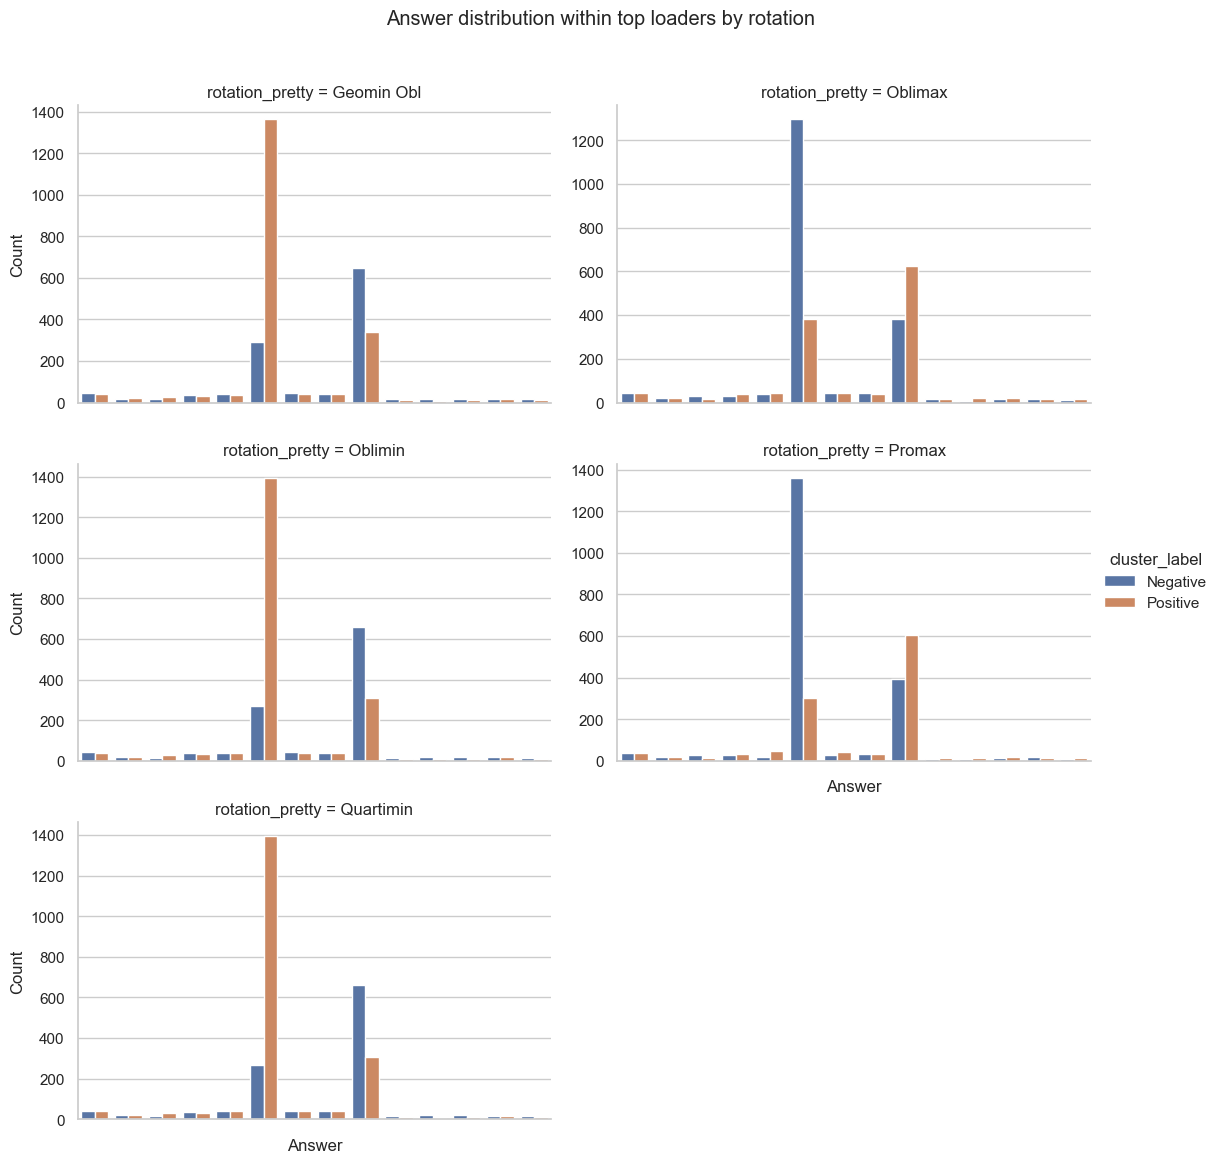

In [50]:
top_answers = (
    answer_long.groupby(["rotation_pretty", "cluster_label", "answer_label"])
    ["count"]
    .sum()
    .reset_index()
 )

g = sns.catplot(
    data=top_answers,
    x="answer_label",
    y="count",
    hue="cluster_label",
    col="rotation_pretty",
    kind="bar",
    col_wrap=2,
    height=4,
    aspect=1.4,
    sharey=False,
    errorbar=None,
)
g.set_xticklabels(rotation=45)
g.set_axis_labels("Answer", "Count")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle("Answer distribution within top loaders by rotation")
plt.show()

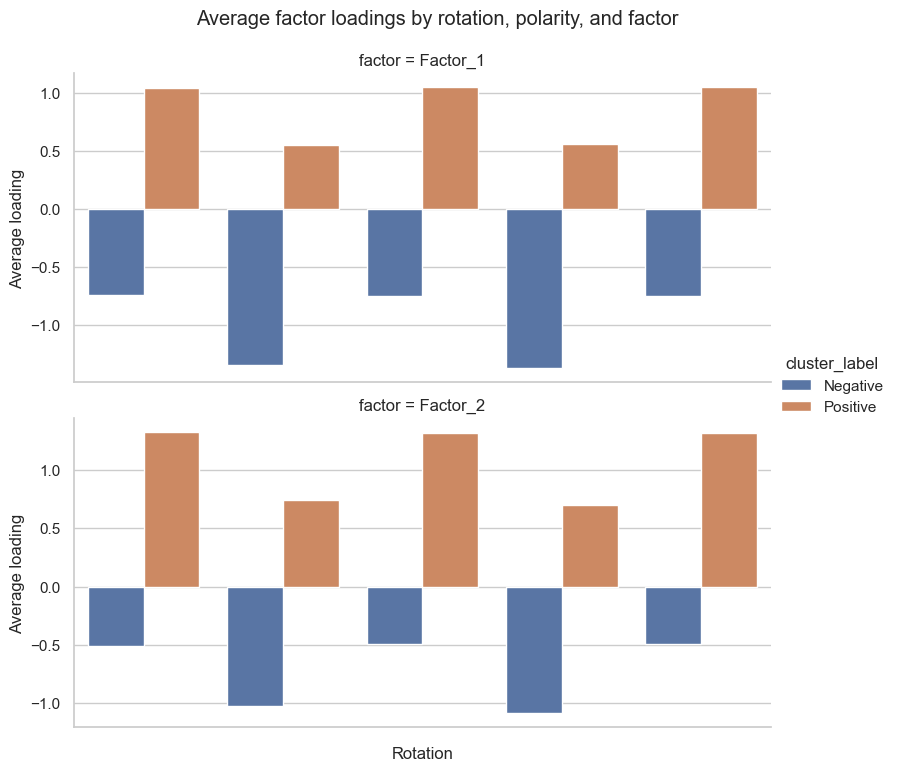

In [51]:
facet = sns.catplot(
    data=plot_summary_df,
    x="rotation_pretty",
    y="loading_mean",
    hue="cluster_label",
    row="factor",
    kind="bar",
    height=4,
    aspect=2,
    sharey=False,
    errorbar=None,
)
facet.set_xticklabels(rotation=30)
facet.set_axis_labels("Rotation", "Average loading")
facet.fig.subplots_adjust(top=0.9)
facet.fig.suptitle("Average factor loadings by rotation, polarity, and factor")
plt.show()

## Notes
- `summary_df` aggregates loading statistics, lexical complexity proxies, certainty estimates from a pretrained classifier, and sentiment (when available) for each *rotation × factor* cluster.
- `type_counts_df` and `answer_counts_df` capture categorical distributions within the top positive/negative loaders.
- `examples_df` holds the first few questions per cluster for quick qualitative review.
- Perplexity-style metrics require specialised language models that are **not** bundled with this environment, so they are not computed here.